In [2]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 13.9 MB/s eta 0:00:0000:010:01mm
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 67.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.8 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 86.6 MB/s eta 0:00:00:00:0100:01



CLASSICAL ML PIPELINE (26-CLASS)

LOADING DATA FOR 26-CLASS PROBLEM
Loaded data with shape: (303481, 6)
Using 5 columns as features.
Using original 26 class labels.

Balancing dataset...
Balancing all 26 classes to 10089 samples each.

DATASET SUMMARY
Total balanced samples: 262314
Training/Validation set: 209851 samples
Test set: 52463 samples

Configuration:
  - Model: XGBoost
  - Classes: 26

TRAINING CLASSICAL XGBOOST MODEL
Training started...
Training finished.

FINAL EVALUATION ON UNSEEN TEST SET

Test Set Accuracy: 0.9394

Detailed Classification Report:
                       precision    recall  f1-score   support

             AESCrypt     0.9950    0.9960    0.9955      2017
               Cerber     0.8893    0.9554    0.9212      2018
    Cerber-largefiles     0.9904    0.9673    0.9787      2018
       Cerber-w10dirs     0.9828    0.9628    0.9727      2018
             Darkside     0.9437    0.9722    0.9578      2018
  Darkside-largefiles     0.9662    0.9643    0.9653

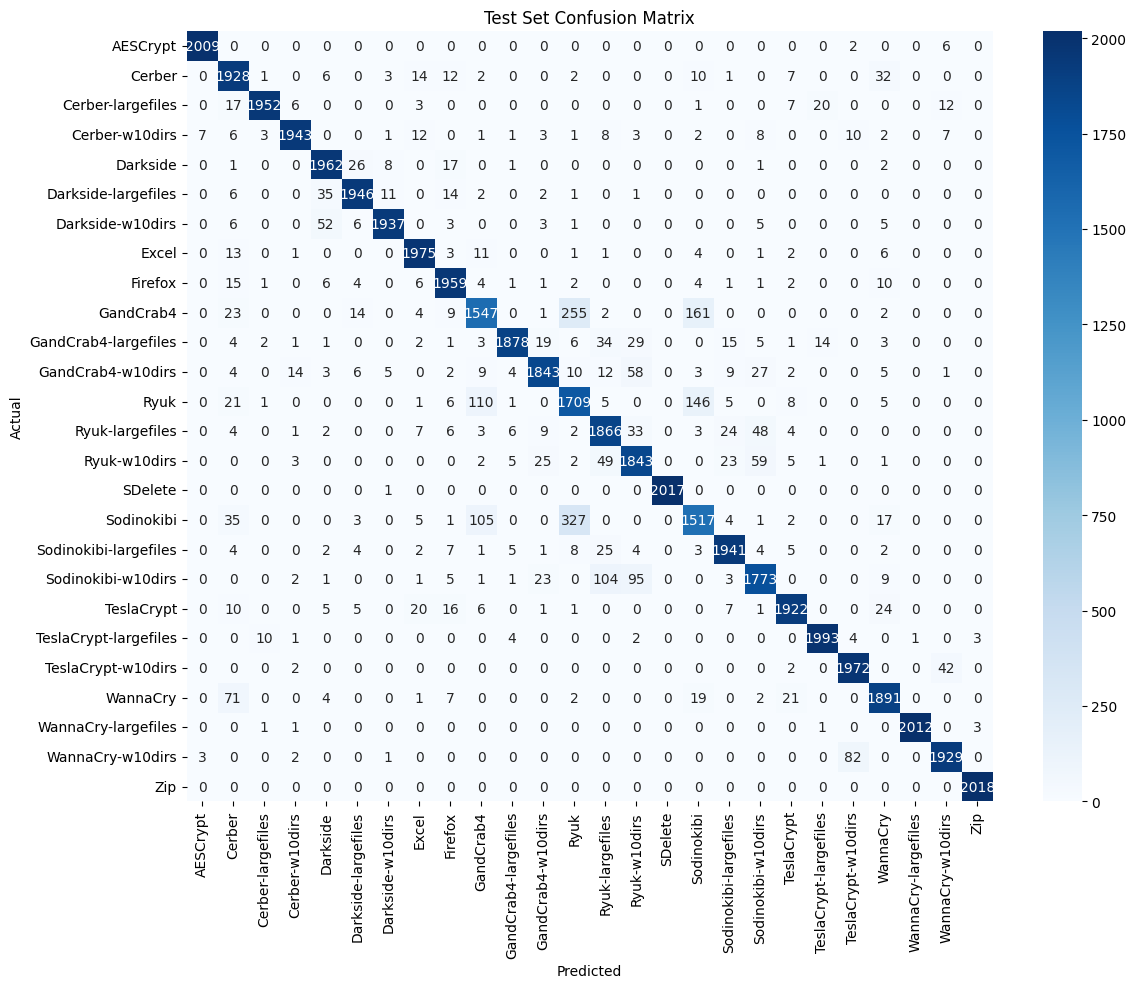



Training pipeline completed successfully!


In [3]:
import torch
import torch.nn as nn
import pennylane as qml
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from pathlib import Path
import random
import warnings
warnings.filterwarnings('ignore')
import os
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# --- Classification Setup ---
CLASS_CONFIG = {
    26: {
        "AESCrypt": 0, "Cerber": 1, "Cerber-largefiles": 2,
        "Cerber-w10dirs": 3, "Darkside": 4, "Darkside-largefiles": 5,
        "Darkside-w10dirs": 6, "Excel": 7, "Firefox": 8,
        "GandCrab4": 9, "GandCrab4-largefiles": 10,
        "GandCrab4-w10dirs": 11, "Ryuk": 12, "Ryuk-largefiles": 13,
        "Ryuk-w10dirs": 14, "SDelete": 15, "Sodinokibi": 16,
        "Sodinokibi-largefiles": 17, "Sodinokibi-w10dirs": 18,
        "TeslaCrypt": 19, "TeslaCrypt-largefiles": 20,
        "TeslaCrypt-w10dirs": 21, "WannaCry": 22,
        "WannaCry-largefiles": 23, "WannaCry-w10dirs": 24, "Zip": 25
    },
    12: {
        "AESCrypt": 0, "Cerber": 1, "Darkside": 2,
        "Excel": 3, "Firefox": 4, "GandCrab4": 5,
        "Ryuk": 6, "SDelete": 7, "Sodinokibi": 8,
        "TeslaCrypt": 9, "WannaCry": 10, "Zip": 11
    },
    2: { "Benign": 0, "Ransomware": 1 }
}
BENIGN_CLASS_IDS_26 = {0, 7, 8, 15, 25}

# --- Data Loading and Transformation ---
def load_data_from_npy(file_path: str, test_ratio: float, num_classes: int, max_samples_per_class: int = None):
    """Loads and processes data for 2, 12, or 26-class classification."""
    print("\n" + "="*50)
    print(f"LOADING DATA FOR {num_classes}-CLASS PROBLEM")
    print("="*50)

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    data = np.load(file_path)
    X = data[:, :-1]
    y = data[:, -1].astype(int)
    print(f"Loaded data with shape: {data.shape}")
    print(f"Using {X.shape[1]} columns as features.")

    # --- Label Transformation ---
    y_processed = None
    if num_classes == 2:
        is_benign_mask = np.isin(y, list(BENIGN_CLASS_IDS_26))
        y_processed = (~is_benign_mask).astype(int)
        print("Labels transformed to binary (0: Benign, 1: Ransomware)")
    elif num_classes == 12:
        id_to_name_26 = {v: k for k, v in CLASS_CONFIG[26].items()}
        y_processed = np.array([
            CLASS_CONFIG[12][id_to_name_26[label].split('-')[0]] for label in y
        ])
        print("Labels mapped from 26 classes to 12 families.")
    elif num_classes == 26:
        y_processed = y
        print("Using original 26 class labels.")
    else:
        raise ValueError("`num_classes` must be 2, 12, or 26.")

    # --- Multi-class Balancing with Sample Limit ---
    print("\nBalancing dataset...")
    unique, counts = np.unique(y_processed, return_counts=True)
    min_samples = np.min(counts)
    
    balance_to = min(min_samples, max_samples_per_class) if max_samples_per_class else min_samples
    
    print(f"Balancing all {len(unique)} classes to {balance_to} samples each.")
    
    balanced_indices = []
    for label in unique:
        indices = np.where(y_processed == label)[0]
        chosen_indices = np.random.choice(indices, balance_to, replace=False)
        balanced_indices.append(chosen_indices)
    
    balanced_indices = np.concatenate(balanced_indices)
    np.random.shuffle(balanced_indices)
    
    X_balanced = X[balanced_indices]
    y_balanced = y_processed[balanced_indices]

    # --- Splitting Data ---
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_balanced, y_balanced, test_size=test_ratio, random_state=42, stratify=y_balanced
    )
    
    print("\n" + "="*50)
    print("DATASET SUMMARY")
    print("="*50)
    print(f"Total balanced samples: {len(X_balanced)}")
    print(f"Training/Validation set: {len(X_train_val)} samples")
    print(f"Test set: {len(X_test)} samples")

    return X_train_val, y_train_val, X_test, y_test

def train_and_evaluate_classical(X_train_val, y_train_val, X_test, y_test, num_classes):
    """
    Trains and evaluates an XGBoost model.
    No cross-validation is needed as XGBoost is robust. We train on the full
    training set and evaluate on the test set.
    """
    print("\n" + "="*50)
    print("TRAINING CLASSICAL XGBOOST MODEL")
    print("="*50)

    # Scaling the data is good practice for most models
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_val)
    X_test_scaled = scaler.transform(X_test)

    # Initialize and train the XGBoost classifier
    # 'tree_method': 'hist' with 'gpu_id=0' enables GPU acceleration
    model = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=num_classes,
        eval_metric='mlogloss',
        use_label_encoder=False,
        n_estimators=200, # Number of boosting rounds
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method='hist', # Use this for GPU support
        gpu_id=0 if torch.cuda.is_available() else -1 # Use GPU 0 if available
    )

    print("Training started...")
    model.fit(X_train_scaled, y_train_val, verbose=True)
    print("Training finished.")

    # --- Final Evaluation on Test Set ---
    print("\n" + "="*50)
    print("FINAL EVALUATION ON UNSEEN TEST SET")
    print("="*50)
    
    test_preds = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, test_preds)
    
    print(f"\nTest Set Accuracy: {test_acc:.4f}")
    
    class_names = list(CLASS_CONFIG[num_classes].keys())
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, test_preds, target_names=class_names, digits=4, zero_division=0))
    
    cm = confusion_matrix(y_test, test_preds)
    plt.figure(figsize=(max(8, len(class_names)//2), max(6, len(class_names)//2.5)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Test Set Confusion Matrix')
    plt.savefig('classical_confusion_matrix.png', dpi=100, bbox_inches='tight')
    plt.show()

    return model

def main_training_pipeline(npy_file_path: str, num_classes: int, max_samples_per_class: int = None):
    print("\n" + "="*60)
    print(f"CLASSICAL ML PIPELINE ({num_classes}-CLASS)")
    print("="*60)
    
    try:
        X_train_val, y_train_val, X_test, y_test = load_data_from_npy(
            file_path=npy_file_path, test_ratio=0.2, num_classes=num_classes,
            max_samples_per_class=max_samples_per_class
        )
        
        print(f"\nConfiguration:")
        print(f"  - Model: XGBoost")
        print(f"  - Classes: {num_classes}")
        
        model = train_and_evaluate_classical(
            X_train_val, y_train_val, X_test, y_test, num_classes
        )
        
        return model
        
    except Exception as e:
        print(f"\nAn error occurred: {e}")
        import traceback
        traceback.print_exc()
        return None

# --- Main Execution ---
if __name__ == "__main__":
    # --- CONFIGURATION ---
    # Choose the number of classes: 2, 12, or 26
    NUM_CLASSES = 26
    
    # Set a sample limit for faster testing, or None to use all available data
    # For XGBoost, you can use the full dataset. Set to e.g., 1000 for a quick test.
    MAX_SAMPLES_PER_CLASS = None
    
    # This dictionary maps your choice of classes to the correct Kaggle file path
    KAGGLE_FILE_PATHS = {
        2: "/kaggle/input/ransap-feature-extracted-ssd-2class/RANSAP_win7-120gb-ssd_2CLASS.npy",
        12: "/kaggle/input/ransap-feature-extracted-ssd-12class/RANSAP_win7-120gb-ssd_12CLASS.npy",
        26: "/kaggle/input/final-feature-extracted-ransap/RANSAP_win7-120gb-ssd_26CLASS.npy"
    }
    
    # Select the correct file path based on the number of classes
    NPY_FILE = KAGGLE_FILE_PATHS[NUM_CLASSES]
    
    if not os.path.exists(NPY_FILE):
        print(f"FATAL: The file was not found -> '{NPY_FILE}'")
    else:
        model = main_training_pipeline(
            npy_file_path=NPY_FILE,
            num_classes=NUM_CLASSES,
            max_samples_per_class=MAX_SAMPLES_PER_CLASS
        )
        if model:
            print("\n\nTraining pipeline completed successfully!")

